# ATiG 2026: LT-FH exercise using ltpred — worked answers

## What you will learn

The [ltpred tutorial](https://bvilhjal.github.io/ltpred/tutorial/) builds a simulated register whose genetic liability is known. This exercise measures the shortcuts that tutorial names. No real data are used.

In class (Parts A and B, one hour):

- **A.** A wrong h² rescales the score. The ranking barely moves.
- **B.** The score is a posterior mean, not a risk. Correlation with liability is not accuracy.

Homework: **C** the score against a 0/1 family-history indicator; **D** h² from parent–offspring pairs, then a case-cohort; **E** observed-scale versus liability-scale h².

Write what you expect before each part. The product is the Q15 note.

LT-FH++ ([Pedersen et al. 2022](https://doi.org/10.1016/j.ajhg.2022.01.009)) is LT-FH ([Hujoel et al. 2020](https://doi.org/10.1038/s41588-020-0613-6)) with age of onset. ADuLT ([Pedersen et al. 2023](https://doi.org/10.1038/s41467-023-41210-z)) drops the family history. Scores use the Pearson–Aitken engine of PA-FGRS ([Krebs et al. 2024](https://doi.org/10.1016/j.ajhg.2024.09.009); [2026](https://doi.org/10.1016/j.ajhg.2025.11.016)). Model: [algorithm page](https://bvilhjal.github.io/ltpred/algorithm/).


## Setup

Install Git, Python, NumPy, SciPy and ltpred from the [setup page](https://bvilhjal.github.io/ATIG_2026/setup.html) (macOS, Windows, or Anaconda). Then run the cell below. Part 0 takes about a minute and needs under 1 GB of memory. Executed with ltpred 0.7.0 (commit `2d85ce9`); the printouts are identical under NumPy 1.26 to 2.5.


In [1]:
import numpy as np
from scipy.stats import norm, rankdata

import ltpred
print("ltpred", ltpred.__version__)

ltpred 0.7.0


## Part 0. Rebuild the tutorial register, then a larger one

The first three cells are tutorial steps 1, 3 and 4 with the tutorial's seeds, so
`cohort`, `scores`, `est`, `predicted` and `at_risk` are the tutorial's names and
the checkpoints match its printouts. Part A uses this register.

The tutorial register has 81 diagnoses, and 71 of them fall after age 40. That
is enough to see an effect and not enough to measure one, so the fourth cell
builds a five-times larger register, `big`, and scores it the same two ways.
Parts B to D use `big`.

In [2]:
from ltpred import simulate_pedigree, simulate_register_liabilities

H2 = 0.5                                      # liability-scale heritability
CIP_K, CIP_MID, CIP_SLOPE = 0.10, 60.0, 1.0 / 8.0
EVAL_AGE = 70.0                               # everyone is followed to here
INDEX_AGE = 40.0                              # the prospective cut in step 4

# the generating cumulative-incidence curve, on a 1-year age grid
AGE_GRID = np.arange(0, 121, 1.0)
TRUE_CIP = CIP_K / (1.0 + np.exp((CIP_MID - AGE_GRID) * CIP_SLOPE))

ids, father, mother = simulate_pedigree(
    np.random.default_rng(20260921), n_founder_pairs=100, gens=2)

cohort = simulate_register_liabilities(
    np.random.default_rng(20260921), ids, father, mother,
    h2=H2, cip_ages=AGE_GRID, cip_values=TRUE_CIP, eval_age=EVAL_AGE)

print(f"{len(ids)} people, {int(cohort.status.sum())} diagnosed by age "
      f"{EVAL_AGE:.0f} ({cohort.status.mean():.1%})")
print(f"var(true genetic liability) = {cohort.genetic.var():.4f}  (target {H2})")

984 people, 81 diagnosed by age 70 (8.2%)
var(true genetic liability) = 0.5083  (target 0.5)


**Checkpoint.** 984 people, 81 diagnosed, variance 0.5083: tutorial step 1.
`cohort.genetic` is the truth that Part A compares against.

In [3]:
from ltpred import estimate_liabilities

scores = estimate_liabilities(
    cohort.ids, cohort.father, cohort.mother,
    probands=cohort.ids,
    status=cohort.status.astype(int), age=cohort.age,
    use="gwas",                          # the proband's own diagnosis is used
    cip_ages=AGE_GRID, cip_values=TRUE_CIP, k_pop=CIP_K,
    h2=H2)

est = np.asarray(scores.est)
print(f"corr(score, true genetic liability) = {np.corrcoef(est, cohort.genetic)[0, 1]:.4f}")
print(f"score sd = {est.std():.4f}   mean posterior variance = {np.asarray(scores.var).mean():.4f}")

corr(score, true genetic liability) = 0.5502
score sd = 0.3898   mean posterior variance = 0.3558


In [4]:
at_risk = cohort.onset > INDEX_AGE          # still undiagnosed at the cut
index_time = cohort.birth_time + INDEX_AGE
probands_at_risk = [p for p, keep in zip(cohort.ids, at_risk) if keep]

predicted = estimate_liabilities(
    cohort.ids, cohort.father, cohort.mother,
    probands=probands_at_risk,
    status=cohort.status.astype(int), age=cohort.age,
    use="prediction",                    # the proband's own diagnosis is hidden
    cip_ages=AGE_GRID, cip_values=TRUE_CIP, k_pop=CIP_K, h2=H2,
    birth_time=cohort.birth_time, index_time=index_time[at_risk])

pred_est = np.asarray(predicted.est)
print(f"{int(at_risk.sum())} of {len(ids)} probands are disease-free at age {INDEX_AGE:.0f}")
print(f"corr(score, truth) = {np.corrcoef(pred_est, cohort.genetic[at_risk])[0, 1]:.4f}"
      f"   score sd = {pred_est.std():.4f}")

974 of 984 probands are disease-free at age 40
corr(score, truth) = 0.3069   score sd = 0.2134


**Checkpoint.** Correlations 0.5502 and 0.3069: tutorial steps 3 and 4. Step 3
also noted that 0.390² + 0.356 = 0.508, the variance of `cohort.genetic`: the
variance of the scores plus the mean posterior variance recovers Var(g). Part A
asks what becomes of that identity when h² is wrong.

In [5]:
big_ids, big_father, big_mother = simulate_pedigree(
    np.random.default_rng(1), n_founder_pairs=500, gens=2)
big = simulate_register_liabilities(
    np.random.default_rng(1), big_ids, big_father, big_mother,
    h2=H2, cip_ages=AGE_GRID, cip_values=TRUE_CIP, eval_age=EVAL_AGE)


def score_big(use, h2=H2):
    """Score `big` as tutorial step 3 (use="gwas") or step 4 (use="prediction")."""
    prospective = use == "prediction"
    keep = big.onset > INDEX_AGE if prospective else np.ones(len(big.ids), bool)
    return estimate_liabilities(
        big.ids, big.father, big.mother,
        probands=[p for p, k in zip(big.ids, keep) if k],
        status=big.status.astype(int), age=big.age, use=use,
        cip_ages=AGE_GRID, cip_values=TRUE_CIP, k_pop=CIP_K, h2=h2,
        birth_time=big.birth_time if prospective else None,
        index_time=(big.birth_time + INDEX_AGE)[keep] if prospective else None)


big_gwas = score_big("gwas")                 # every person, own diagnosis used
big_pred = score_big("prediction")           # disease-free at 40, own diagnosis hidden
big_est = np.asarray(big_gwas.est)
big_at_risk = big.onset > INDEX_AGE
big_m, big_v = np.asarray(big_pred.est), np.asarray(big_pred.var)

print(f"{len(big.ids)} people, {int(big.status.sum())} diagnosed by age 70 "
      f"({big.status.mean():.1%}); var(genetic) = {big.genetic.var():.4f}")
print(f"use='gwas':       corr(score, truth) = {np.corrcoef(big_est, big.genetic)[0, 1]:.4f}")
print(f"use='prediction': corr(score, truth) = "
      f"{np.corrcoef(big_m, big.genetic[big_at_risk])[0, 1]:.4f} on "
      f"{int(big_at_risk.sum())} probands disease-free at 40")

5075 people, 366 diagnosed by age 70 (7.2%); var(genetic) = 0.4932
use='gwas':       corr(score, truth) = 0.5222
use='prediction': corr(score, truth) = 0.2781 on 5037 probands disease-free at 40


**Checkpoint.** 5,075 people and 366 diagnoses. The two correlations, 0.52 and
0.28, are the tutorial's 0.55 and 0.31 on a register with the same generating
model but five times the people; the difference is sampling noise and the
pedigree mix, not a change in the method.

## Part A. What does a wrong h² do?

Step 3 passed the true `h2=0.5`. In a real analysis h² is an external estimate for
the disease on the liability scale, and it has no default: the
[method guide](https://bvilhjal.github.io/ltpred/guide/) says to prefer an external estimate or to cross-check it.
Here you can pass a wrong value on purpose and compare with the truth. Part A
uses the tutorial register, `cohort`.

### Q1: If you tell the scorer h² = 0.8 when the truth is 0.5, do the scores spread more or less? Does their ranking change?

**Before running:** write your expectation down with one sentence of reasoning.
The scorer's model says that a fraction h² of the liability variance is genetic
and shared with relatives.

**Answer.** With h² = 0.8 the scorer believes that relatives, and the proband's
own status, say more about the genetic liability than they do, so every score
moves further from zero: the spread grows. The ranking changes little, because the
same observations still point the same way; only their weights change. Q2 checks
both claims.

### Q2: Score the register under h² = 0.2, 0.5 and 0.8 and tabulate the consequences.

For each assumed value, score `cohort` with `use="gwas"` exactly as in Part 0 and
print five numbers: the correlation with `cohort.genetic`; the variance of the
scores; the mean posterior variance `s.var`; their sum; and the slope of
`cohort.genetic` regressed on the score, `np.polyfit(e, cohort.genetic, 1)[0]`.

In [6]:
by_h2 = {}
print(f"{'assumed h2':>10} {'corr':>7} {'var(score)':>11} {'mean var':>9} {'sum':>7} {'slope':>7}")
for h2_assumed in (0.2, 0.5, 0.8):
    s = estimate_liabilities(
        cohort.ids, cohort.father, cohort.mother, probands=cohort.ids,
        status=cohort.status.astype(int), age=cohort.age, use="gwas",
        cip_ages=AGE_GRID, cip_values=TRUE_CIP, k_pop=CIP_K,
        h2=h2_assumed)
    e, v = np.asarray(s.est), np.asarray(s.var)
    corr = np.corrcoef(e, cohort.genetic)[0, 1]
    slope = np.polyfit(e, cohort.genetic, 1)[0]
    by_h2[h2_assumed] = (e, slope)
    print(f"{h2_assumed:>10.1f} {corr:>7.4f} {e.var():>11.4f} {v.mean():>9.4f} "
          f"{e.var() + v.mean():>7.4f} {slope:>7.3f}")

assumed h2    corr  var(score)  mean var     sum   slope


       0.2  0.5488      0.0398    0.1716  0.2113   1.962


       0.5  0.5502      0.1520    0.3558  0.5077   1.006


       0.8  0.5395      0.3025    0.4791  0.7816   0.699


**Answer.** The correlation is 0.549, 0.550 and 0.540: the ranking barely notices.
Everything on the variance scale follows the assumed value instead of the truth.
The `sum` column reads 0.21, 0.51 and 0.78: the decomposition
Var(score) + mean posterior variance adds up to the h² the model was told, not to
the 0.5 that generated the data. The slope of truth on score is 1.96, 1.01 and
0.70. The figure shows the same thing: only the middle panel's fitted line lies on
the identity line.

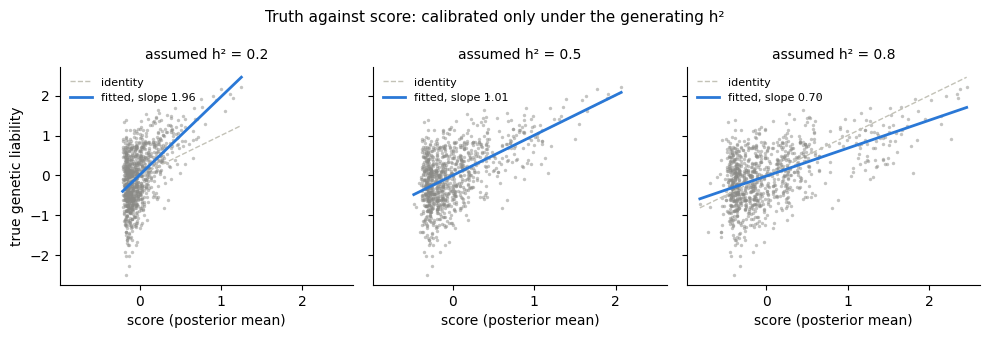

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), sharex=True, sharey=True)
for ax, (h2_assumed, (e, slope)) in zip(axes, by_h2.items()):
    ax.scatter(e, cohort.genetic, s=6, color="#8a8a86", alpha=0.5, linewidths=0)
    grid = np.linspace(e.min(), e.max(), 2)
    ax.plot(grid, grid, color="#c3c2b7", lw=1, ls="--", label="identity")
    intercept = np.polyfit(e, cohort.genetic, 1)[1]
    ax.plot(grid, slope * grid + intercept, color="#2a78d6", lw=2,
            label=f"fitted, slope {slope:.2f}")
    ax.set_title(f"assumed h² = {h2_assumed}", fontsize=10)
    ax.set_xlabel("score (posterior mean)")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0].set_ylabel("true genetic liability")
fig.suptitle("Truth against score: calibrated only under the generating h²", fontsize=11)
fig.tight_layout()

### Q3: Which columns moved and which did not? What does a slope of 1 mean, and why does only the right h² give it?

A posterior mean is *calibrated* when the truth regressed on it has slope 1: among
probands scored 0.3, the true liability averages 0.3. Relate your slopes to the
guide's advice on h². Optional: scatter `cohort.genetic` against the score for
each h² and draw the fitted line.

**Answer.** The correlation column stayed put; the three variance columns and the
slope moved. A posterior mean is calibrated by construction under its own model:
E[g | data] regressed on itself has slope 1, so among probands scored 0.3 the true
liability averages 0.3. Only the model with the right variance components is the
model the data came from. Under h² = 0.2 the scores are too timid, and the truth
moves twice as fast as the score; under 0.8 they are too bold.

A GWAS that uses the score as a phenotype is a ranking exercise and survives a
wrong h². Anything that reads the score's scale does not: the risk in Part B, a
comparison of scores across diseases, or the variance a polygenic score explains
in the family-history phenotype. That is why the guide asks for an external
liability-scale h², or a cross-check such as Part D.

## Part B. Who becomes a case between 40 and 70?

![Liability thresholds at 40 and 70. Higher liability is earlier onset. Prospective probands are still left of T40; an incident case has crossed T70.](figures/thresholds.png)

Step 4's correlation, 0.31, is not the accuracy of predicting a later case. Measure it on `big`. Probands in `big_pred` are still left of T40. An incident case is one of them who has crossed T70 by age 70.


### Q4: How many probands become incident cases, and what is the incidence?

Hint: `big.status` means "diagnosed by 70" and `big_at_risk` means "undiagnosed at
40". Combine them, then index with `big_at_risk` so that the result lines up with
`big_m`.

In [8]:
y = (big_at_risk & big.status)[big_at_risk]
print(f"{int(y.sum())} incident cases among {len(y)} probands ({y.mean():.1%})")

328 incident cases among 5037 probands (6.5%)


**Answer.** 328 incident cases among 5,037 probands, 6.5%. The 38 people
diagnosed before 40 are not in `big_pred`: step 4 excluded them because scoring a
prevalent case and calling it prospective is leakage. The tutorial register has
71 such cases; that is why Part B moved to `big`.

### Q5: Compute the AUC for three predictors of that outcome on the same probands.

The AUC is the probability that a random incident case scores above a random
non-case. With ranks from `scipy.stats.rankdata` it is the Mann–Whitney statistic:
if `r` are the ranks of the predictor, `n1` the number of cases and `n0` the number
of non-cases, AUC = (sum of the cases' ranks − n1(n1 + 1)/2) / (n1 · n0).

The predictors: the prospective score `big_m`; the true genetic liability
`big.genetic[big_at_risk]`, which is the ceiling for any predictor built from
genetics alone; and the `use="gwas"` score `big_est` restricted to the same
people, which used each proband's own diagnosis.

**Before running:** order the three AUCs.

In [9]:
def auc(x, y):
    r = rankdata(x)
    n1, n0 = y.sum(), (~y).sum()
    return (r[y].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

def auc_se(x, y):
    # Hanley & McNeil (1982) standard error
    a = auc(x, y)
    n1, n0 = y.sum(), (~y).sum()
    q1, q2 = a / (2 - a), 2 * a**2 / (1 + a)
    return np.sqrt((a * (1 - a) + (n1 - 1) * (q1 - a**2) + (n0 - 1) * (q2 - a**2)) / (n1 * n0))

for label, x in (("prospective score", big_m),
                 ("true genetic liability", big.genetic[big_at_risk]),
                 ("use='gwas' score, same people", big_est[big_at_risk])):
    print(f"AUC {label:30s} = {auc(x, y):.3f} +/- {auc_se(x, y):.3f}")

AUC prospective score              = 0.605 +/- 0.017
AUC true genetic liability         = 0.887 +/- 0.012
AUC use='gwas' score, same people  = 0.995 +/- 0.003


**Answer.** The `use="gwas"` score 0.995, the true genetic liability 0.887, the
prospective score 0.605. With 328 events the Hanley–McNeil standard errors are
0.003, 0.012 and 0.017, so the three are many standard errors apart. On the
tutorial register the same three AUCs are 0.99, 0.87 and 0.61 with standard
errors twice as large.

### Q6: Why is the ceiling below 1 although it is the truth? Where does the gap between the prospective score and the ceiling come from? What does the third AUC say about `use="gwas"` in a prospective claim?

On `big`, print `big_m.var()`, `big_est.var()` and `np.asarray(big_gwas.var).mean()`, next to `big.genetic.var()`. The retrospective score saw each proband's own diagnosis. The prospective score did not.


**Answer.** The outcome depends on the full liability g + e, and the residual e
has variance 1 − h² = 0.5 that no genetic quantity can see. Even perfect knowledge
of g predicts incident disease with an AUC of 0.89 here; a ceiling of 1 would need
h² = 1.

The prospective score knows g only through relatives. With the proband's own
diagnosis included, the data identified 0.129 of Var(g) = 0.49 and left 0.359 as
posterior uncertainty; hiding that diagnosis identifies less still (the
prospective score's variance is 0.040). The score is therefore a shrunken, noisy
version of g, and its AUC sits at 0.61.

The third AUC, 0.995, is what leakage looks like. The `use="gwas"` score contains
the proband's own diagnosis, which is the outcome, so a "prospective" evaluation of
it evaluates the outcome against itself. Step 4's `proband_state` check exists to
catch this.

### Q7: Turn the score into a risk and check it against the observed incidence.

`big_m` is not a probability. Given the relatives, full liability is Normal with mean `m = big_m` and variance `s² = big_v + 1 − h²`, because `use="prediction"` left the proband's own status out. With `T_a = Φ⁻¹(1 − CIP(a))` as in the figure,

risk = [Φ((T40 − m)/s) − Φ((T70 − m)/s)] / Φ((T40 − m)/s).

Compute it for every proband. Compare the mean with the Q4 incidence, then within fifths of `big_m`.


In [10]:
m, v = big_m, big_v
T40 = norm.ppf(1.0 - np.interp(INDEX_AGE, AGE_GRID, TRUE_CIP))
T70 = norm.ppf(1.0 - np.interp(EVAL_AGE, AGE_GRID, TRUE_CIP))
s = np.sqrt(v + 1.0 - H2)
p_free_at_40 = norm.cdf((T40 - m) / s)
risk = (p_free_at_40 - norm.cdf((T70 - m) / s)) / p_free_at_40

print(f"mean model risk {risk.mean():.4f}   observed incidence {y.mean():.4f}")

fifths = np.array_split(np.argsort(m, kind="stable"), 5)
for label, g in zip(("lowest", "second", "middle", "fourth", "highest"), fifths):
    print(f"{label:>8} fifth  n={len(g)}  events={int(y[g].sum()):3d}  "
          f"observed {y[g].mean():.3f}  model risk {risk[g].mean():.3f}")

mean model risk 0.0697   observed incidence 0.0651
  lowest fifth  n=1008  events= 44  observed 0.044  model risk 0.044
  second fifth  n=1008  events= 52  observed 0.052  model risk 0.056
  middle fifth  n=1007  events= 49  observed 0.049  model risk 0.062
  fourth fifth  n=1007  events= 76  observed 0.075  model risk 0.070
 highest fifth  n=1007  events=107  observed 0.106  model risk 0.117


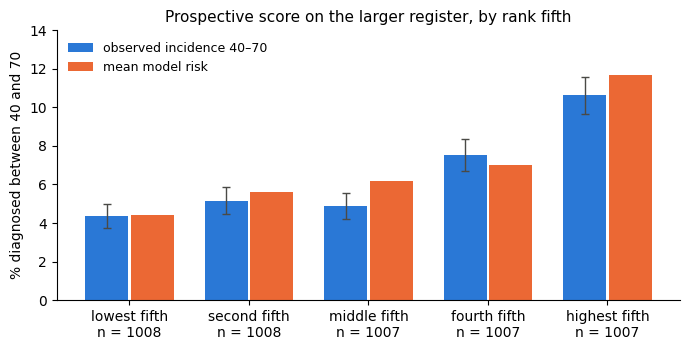

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.6))
labels = ("lowest", "second", "middle", "fourth", "highest")
obs = np.array([y[g].mean() for g in fifths])
mod = np.array([risk[g].mean() for g in fifths])
n = np.array([len(g) for g in fifths])
x = np.arange(5)
ax.bar(x - 0.19, 100 * obs, width=0.36, color="#2a78d6", label="observed incidence 40–70")
ax.errorbar(x - 0.19, 100 * obs, yerr=100 * np.sqrt(obs * (1 - obs) / n),
            fmt="none", ecolor="#4a4a46", elinewidth=1, capsize=3)
ax.bar(x + 0.19, 100 * mod, width=0.36, color="#eb6834", label="mean model risk")
ax.set_xticks(x, [f"{l} fifth\nn = {k}" for l, k in zip(labels, n)])
ax.set_ylim(0, 14)
ax.set_ylabel("% diagnosed between 40 and 70")
ax.set_title("Prospective score on the larger register, by rank fifth", fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="upper left")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
fig.tight_layout()

**Answer.** Mean model risk 6.97% against an observed 6.51%, 1.3 standard errors
apart: the model's absolute risk is calibrated in the large, as it must be when
the model generated the data. By rank fifth the observed incidence is 4.4%, 5.2%,
4.9%, 7.5% and 10.6% against model risks of 4.4%, 5.6%, 6.2%, 7.0% and 11.7%; each
fifth holds 44 to 107 events, so the error bars are 0.6 to 1.0 percentage points.
The top fifth carries 2.4 times the risk of the bottom fifth, and the middle
three are hard to tell apart: that is what an AUC of 0.61 looks like as absolute
risk.

The risk needed `big_v` because two probands with the same score but a different
number of informative relatives have a different posterior spread, and a wider
spread pushes more probability past the threshold. That is why the scorer returns
a variance next to every mean. It is also where Part A comes back: s² uses h²
twice, once inside the posterior variance and once as 1 − h², so a wrong h²
produces a confidently wrong risk. ltpred's algorithm page relates this
construction to
[Sham's liability-threshold risk models](https://bvilhjal.github.io/ltpred/algorithm/#connection-to-shams-liability-threshold-risk-models).

## Part C. What the score buys over a 0/1 indicator (homework)

The usual alternative to a family-history score is the crude indicator "any
first-degree relative diagnosed", the covariate a GWAS might adjust for. This part
puts it next to the score on `big`, both retrospectively and prospectively.

### Q8: How much does the score improve on a 0/1 family-history indicator?

For every person in `big`, compute (i) their own status, (ii) a 0/1 indicator of
any diagnosed first-degree relative (a parent or a full sibling, not the proband),
and (iii) the count of diagnosed first-degree relatives, all with follow-up to 70.
Compare their R² against `big.genetic` with that of the `use="gwas"` score
`big_est`, which also saw everything to age 70.

Then compare prospectively. The fair opponent of `big_m` is an indicator that
knows only what was known at the proband's 40th birthday, so recompute (ii) and
(iii) counting a relative only if `big.birth_time + big.onset` is at or before the
proband's index time. Report their AUCs for the Part B outcome. Why is own status
missing from the prospective comparison?

In [12]:
big_idx = {p: i for i, p in enumerate(big.ids)}
sibs = {}                                     # children grouped by (father, mother)
for i, (fa, mo) in enumerate(zip(big.father, big.mother)):
    if fa in big_idx and mo in big_idx:
        sibs.setdefault((fa, mo), []).append(i)


def first_degree(i):
    """Row indices of person i's parents and full siblings present in the register."""
    fa, mo = big.father[i], big.mother[i]
    rels = [big_idx[p] for p in (fa, mo) if p in big_idx]
    if fa in big_idx and mo in big_idx:
        rels += [j for j in sibs[(fa, mo)] if j != i]
    return np.asarray(rels, int)


relatives = [first_degree(i) for i in range(len(big.ids))]
big_index_time = big.birth_time + INDEX_AGE

n_fdr = np.array([big.status[r].sum() for r in relatives], float)
n_fdr_40 = np.array([(big.birth_time[r] + big.onset[r] <= big_index_time[i]).sum()
                     for i, r in enumerate(relatives)], float)
fh01, fh01_40 = (n_fdr > 0).astype(float), (n_fdr_40 > 0).astype(float)
print(f"FH-positive: {int(fh01.sum())} of {len(fh01)} with follow-up to 70, "
      f"{int(fh01_40.sum())} at the proband's 40th birthday")

for name, x in (("own status", big.status.astype(float)), ("FH indicator 0/1", fh01),
                ("# affected FDRs", n_fdr), ("use='gwas' score", big_est)):
    print(f"R2  {name:18s} {np.corrcoef(x, big.genetic)[0, 1] ** 2:.3f}")
for name, x in (("FH indicator 0/1 at 40", fh01_40[big_at_risk]),
                ("# affected FDRs at 40", n_fdr_40[big_at_risk]),
                ("prospective score", big_m)):
    print(f"AUC {name:22s} {auc(x, y):.3f}")

FH-positive: 954 of 5075 with follow-up to 70, 609 at the proband's 40th birthday
R2  own status         0.145
R2  FH indicator 0/1   0.068
R2  # affected FDRs    0.075
R2  use='gwas' score   0.273
AUC FH indicator 0/1 at 40 0.562
AUC # affected FDRs at 40  0.563
AUC prospective score      0.605


**Answer.** Prospectively, where own status separates nobody, the indicator known at 40 has AUC 0.562, the count 0.563, and the score 0.605, against a genetic ceiling of 0.887. Only 609 people are FH-positive at 40.

With follow-up to 70 the indicator flags 954 of 5,075 people and explains 6.8% of genetic variance, the count 7.5%, own diagnosis 14.5%, and the `use="gwas"` score 27.3%. The factor of four also uses the proband's own status, who is affected, and age.


## Part D. Where does h² come from? (homework)

Part A showed that h² is not a nuisance parameter. The [method guide](https://bvilhjal.github.io/ltpred/guide/)
suggests a cross-check: h² is about twice a first-degree tetrachoric correlation,
and `ltpred.tetrachoric` estimates one from the 2×2 table of two binary statuses.
This part runs the cross-check on both registers, asks why it works, and then
breaks it with a realistic sampling design.

### Q9: Estimate h² from parent–offspring pairs in the tutorial register, then in `big`.

Pair every person with each parent whose id is in the table (both parents give a
pair) and call `tetrachoric(parent_status, child_status)`. Report the 2×2 table
and 2ρ ± 2 SE for `cohort` and for `big`.

In [13]:
from ltpred.tetrachoric import tetrachoric, tetrachoric_table


def parent_offspring_status(reg):
    idx = {p: i for i, p in enumerate(reg.ids)}
    parent, child = [], []
    for kid, fa, mo in zip(reg.ids, reg.father, reg.mother):
        for par in (fa, mo):
            if par in idx:

                parent.append(reg.status[idx[par]])
                child.append(reg.status[idx[kid]])

    return np.asarray(parent), np.asarray(child)


def table(parent, child):
    """Counts: both diagnosed, parent only, child only, neither."""
    return np.array([(parent & child).sum(), (parent & ~child).sum(),
                     (~parent & child).sum(), (~parent & ~child).sum()])


for label, reg in (("tutorial register", cohort), ("larger register", big)):
    par, kid = parent_offspring_status(reg)
    t = tetrachoric(par, kid)
    print(f"{label:17s}: {len(par):5d} pairs, table {table(par, kid)}  ->  "
          f"h2 = {2 * t.rho:+.2f} +/- {2 * t.se:.2f}   (truth {H2})")

tutorial register:  1528 pairs, table [  20  118   90 1300]  ->  h2 = +0.47 +/- 0.15   (truth 0.5)


larger register  :  7884 pairs, table [  90  489  460 6845]  ->  h2 = +0.52 +/- 0.07   (truth 0.5)


**Answer.** The tutorial register gives h² = 0.47 ± 0.15 from 1,528 pairs, and
`big` gives 0.52 ± 0.07 from 7,884 pairs. The tables show where the information is:
20 and 90 pairs in which both are diagnosed. Everything else is the margin. Five
times the people gives about half the standard error, the rate for independent
pairs. The pairs share people, so that SE is somewhat too small.


### Q10: Why does twice the tetrachoric work here, and what would break it in a real register?

Consider what the tetrachoric assumes about the threshold, what this simulation
assumes about shared environment, and how the register was sampled.

**Answer.** Twice the parent–offspring tetrachoric estimates h² when three things
hold. First, both statuses are dichotomised at one common threshold; that holds
here because everyone is followed to 70 and status means "diagnosed by 70".
Second, the parent–offspring liability covariance is h²/2 and nothing else; that
holds because this simulation has no shared environment and no assortative mating.
Third, the pairs are a population sample.

A real register breaks the first assumption first: people have different
follow-up ages and birth cohorts, so one status column mixes thresholds. That is
the problem the age- and cohort-specific thresholds of LT-FH++ solve, and the
reason step 2 of the tutorial estimated an incidence curve. Shared environment
inflates 2ρ; a sibling tetrachoric would show it, and ltpred's fitters model it as
a `C` component. The third assumption is Q11.

### Q11: Run the cross-check on an iPSYCH-style case-cohort.

Real registers are often case-enriched. iPSYCH, for instance, holds every person
diagnosed with one of its disorders in its birth cohorts plus a random sample of
the rest, so the sample's case share far exceeds the prevalence. From `big`, keep
every diagnosed person and each undiagnosed person with probability 0.2 (seed
20260924). Report the sample's case rate against the population's, then estimate
h² from its parent–offspring pairs as in Q9.

Then undo the design. Each kept pair represents 1/(π_parent · π_child) pairs of
the population, where π is 1 for a case and 0.2 for a control. Sum those weights
per cell of the 2×2 table, compare the result with `big`'s table from Q9, and
run `tetrachoric_table` on the rounded weighted counts.

In [14]:
Q_KEEP = 0.2
keep = big.status | (np.random.default_rng(20260924).random(len(big.ids)) < Q_KEEP)
pi = np.where(big.status, 1.0, Q_KEEP)                  # inclusion probability

par, kid, w = [], [], []
for i in np.flatnonzero(keep):
    for p in (big.father[i], big.mother[i]):
        if p in big_idx and keep[big_idx[p]]:
            par.append(big.status[big_idx[p]])
            kid.append(big.status[i])
            w.append(1.0 / (pi[big_idx[p]] * pi[i]))
par, kid, w = np.asarray(par), np.asarray(kid), np.asarray(w)

t = tetrachoric(par, kid)
print(f"kept {int(keep.sum())} of {len(big.ids)}: case rate "
      f"{big.status[keep].mean():.1%} vs {big.status.mean():.1%} in the population")
print(f"{len(par)} pairs, table {table(par, kid)}  ->  naive h2 = {2 * t.rho:+.2f} +/- {2 * t.se:.2f}")

weighted = np.array([w[par & kid].sum(), w[par & ~kid].sum(),
                     w[~par & kid].sum(), w[~par & ~kid].sum()])
tw = tetrachoric_table(*np.round(weighted).astype(int))
t_pop = tetrachoric(*parent_offspring_status(big))
print(f"weighted table {np.round(weighted).astype(int)}  ->  h2 = {2 * tw.rho:+.2f}")
print(f"big's own table {table(*parent_offspring_status(big))}  ->  h2 = {2 * t_pop.rho:+.2f}")
# the weighted table has the population's size, so its own SE is far too small;
# rescale the cells to the number of pairs actually observed for an honest one
scaled = np.round(weighted / weighted.sum() * len(par)).astype(int)
print(f"SE at the {len(par)} pairs actually kept: +/- {2 * tetrachoric_table(*scaled).se:.2f}")

kept 1321 of 5075: case rate 27.7% vs 7.2% in the population
536 pairs, table [ 90 105  89 252]  ->  naive h2 = +0.65 +/- 0.13
weighted table [  90  525  445 6300]  ->  h2 = +0.47
big's own table [  90  489  460 6845]  ->  h2 = +0.52
SE at the 536 pairs actually kept: +/- 0.25


**Answer.** 1,321 of 5,075 people are kept, every case and a fifth of the
controls, at a 27.7% case rate against the population's 7.2%. The naive
tetrachoric reads 2ρ = 0.65 ± 0.13: concordant pairs are oversampled, so the 2×2
table no longer belongs to a population threshold model, and the marginal case
rates the tetrachoric reads its thresholds from are wrong. The weights undo the
design: the weighted table, 90 / 525 / 445 / 6,300, sits next to `big`'s own
90 / 489 / 460 / 6,845, and its estimate returns to 0.47. The honest standard
error is 0.25, because only 536 pairs were observed: the correction removes the
bias, and the design has spent most of the information about h².

This is the sampling contract ltpred's `fit_heritability` demands. Every case plus
random controls has a known, positive inclusion probability for every person and
can be reweighted (`sampling="ipw"`); ascertainment through an affected proband
alone leaves whole strata with probability zero and cannot. Selection never
changes any single family's posterior. What it breaks is the mix of families, and
with it every estimate that reads the population off that mix.

## Part E. Which scale is h² on? (homework)

![A liability split into a 0/1 outcome. The right tail is the cases, 10% when K = 0.10. Everyone on one side receives the same y.](figures/observed_scale.png)

GREML and LD-score regression report h² on the 0/1 scale. Oversampling cases makes that number depend on the sample case proportion P. With prevalence K and z = φ(Φ⁻¹(1 − K)) ([Lee et al. 2011](https://doi.org/10.1016/j.ajhg.2011.02.002); [2012](https://doi.org/10.1002/gepi.21614)),

h²_liab = h²_obs · K²(1 − K)² / (z² · P(1 − P)).

In a population sample, P = K. `observed_to_liability_h2` and `liability_to_observed_h2` are this map and its inverse. The same P(1 − P) sets Neff = 4 N₁ N₀ / N.

K here is the lifetime prevalence 0.10 given to the scorer. "Diagnosed by 70" has prevalence about 0.078. An h² for that phenotype has to use 0.078.


### Q12: What observed-scale h² would each design report?

The truth is h² = 0.5 with K = 0.10. Use `liability_to_observed_h2` to compute
the h² each design would report: (i) a population sample (`prop_cases=None`),
(ii) a 1:1 case/control study (P = 0.5), and (iii) a 1:4 study (P = 0.2). Convert
each back with `observed_to_liability_h2` and check that you recover 0.5.

In [15]:
from ltpred import observed_to_liability_h2, liability_to_observed_h2

for name, P in (("population sample", None), ("1:1 case/control", 0.5), ("1:4 case/control", 0.2)):
    obs = liability_to_observed_h2(H2, CIP_K, P)
    back = observed_to_liability_h2(obs, CIP_K, P)
    print(f"{name:18s} P={CIP_K if P is None else P:.2f}  h2_obs={float(obs):.4f}  round trip={float(back):.4f}")

population sample  P=0.10  h2_obs=0.1711  round trip=0.5000
1:1 case/control   P=0.50  h2_obs=0.4753  round trip=0.5000
1:4 case/control   P=0.20  h2_obs=0.3042  round trip=0.5000


**Answer.** 0.171, 0.475 and 0.304, each returning to 0.5000 exactly: the
transformation and its inverse share one factor, so the round trip is exact by
construction. The figure is that one h² at every case proportion. The 0/1 scale
compresses most where almost everyone sits on one side of the threshold.

![Observed-scale h² against sample case proportion, for liability h² = 0.50 and K = 0.10.](figures/h2_by_design.png)


### Q13: A GWAS on a population sample reports h² = 0.17. Feed it to the scorer unconverted.

Score `cohort` exactly as in Part A, but at the observed-scale value from Q12 (i)
instead of a liability-scale h². Report the correlation with `cohort.genetic` and
the calibration slope. Which Part A row does this imitate, and why is no error
raised? Then convert the 1:1 and the 1:4 designs' values from Q12 while forgetting
the P factor. What does the scorer do with each result?

In [16]:
def score_cohort(h2):
    s = estimate_liabilities(
        cohort.ids, cohort.father, cohort.mother, probands=cohort.ids,
        status=cohort.status.astype(int), age=cohort.age, use="gwas",
        cip_ages=AGE_GRID, cip_values=TRUE_CIP, k_pop=CIP_K, h2=h2)
    e = np.asarray(s.est)
    return np.corrcoef(e, cohort.genetic)[0, 1], np.polyfit(e, cohort.genetic, 1)[0]


obs_population = float(liability_to_observed_h2(H2, CIP_K, None))
corr, slope = score_cohort(obs_population)
print(f"h2 = {obs_population:.4f} unconverted: corr = {corr:.4f}  slope = {slope:.3f}")

for P in (0.5, 0.2):
    forgotten = float(observed_to_liability_h2(liability_to_observed_h2(H2, CIP_K, P), CIP_K))
    try:
        corr, slope = score_cohort(forgotten)
        print(f"P = {P}: forgetting the P factor gives h2 = {forgotten:.2f}, accepted: "
              f"corr = {corr:.4f}  slope = {slope:.3f}")
    except ValueError as err:
        print(f"P = {P}: forgetting the P factor gives h2 = {forgotten:.2f}, rejected: "
              f"{str(err).split(' -- ')[0]}")

h2 = 0.1711 unconverted: corr = 0.5477  slope = 2.213
P = 0.5: forgetting the P factor gives h2 = 1.39, rejected: h2 must be in (0, 1]


P = 0.2: forgetting the P factor gives h2 = 0.89, accepted: corr = 0.5344  slope = 0.636


**Answer.** Correlation 0.548, slope 2.21: Part A's over-shrunk regime, worse than
the h² = 0.2 row because 0.171 sits further below the truth. No error is raised
because 0.171 is a legal heritability; the scorer cannot know it arrived on the
wrong scale, which is why the method guide insists that the h² passed to it be on
the liability scale.

Forgetting the P factor turns the 1:1 design's 0.475 into 1.39, and the scorer
refuses it: h² must lie in (0, 1]. The 1:4 design's 0.304 becomes 0.89, which is
legal, accepted, and wrong: correlation 0.534, slope 0.64, Part A's over-bold
regime. The mistake that announces itself is the lucky one.

### Q14: How much information does each design carry?

Compute Neff = 4 N₁ N₀ / N for `big` as a population sample (366 cases among
5,075), a 1:1 study of 2,500 cases and 2,500 controls, a biobank GWAS with 5,000
cases and 45,000 controls, and a consortium with 50,000 cases and 150,000
controls. Express Neff/N through P alone. Why do case/control GWAS oversample
cases, and why did Part D's tetrachoric never need P while the Lee transformation
does?

In [17]:
for name, n_case, n_ctrl in (("big, population", int(big.status.sum()), len(big.ids) - int(big.status.sum())),
                             ("1:1 study", 2_500, 2_500),
                             ("biobank 1:9", 5_000, 45_000),
                             ("consortium 1:3", 50_000, 150_000)):
    n = n_case + n_ctrl
    neff = 4 * n_case * n_ctrl / n
    print(f"{name:16s} N={n:7d}  P={n_case / n:.3f}  Neff={neff:8.0f}  Neff/N={neff / n:.3f}")

big, population  N=   5075  P=0.072  Neff=    1358  Neff/N=0.268
1:1 study        N=   5000  P=0.500  Neff=    5000  Neff/N=1.000
biobank 1:9      N=  50000  P=0.100  Neff=   18000  Neff/N=0.360
consortium 1:3   N= 200000  P=0.250  Neff=  150000  Neff/N=0.750


**Answer.** Neff is 1,358, 5,000, 18,000 and 150,000, with Neff/N = 4P(1 − P):
0.27, 1, 0.36 and 0.75. As a population sample `big` carries the information of
about 1,400 balanced people. Per person genotyped, oversampling pays until cases
approach half the sample, but recruiting cases costs more than recruiting
controls, so consortia settle between 1:1 and 1:4 and report Neff so that designs
can be compared on one scale.

Part D's tetrachoric never needed P because it fits a threshold model to the 2×2
table and reads its thresholds off the pairs' own marginal rates, which is also
why Q11's case-cohort broke it: the marginals no longer belonged to the
population. An observed-scale h² is a variance on the sample's 0/1 scale, so the
transformation must be told how the sample was drawn. Neff and the Lee factor meet
in P(1 − P): the same term that discounts a sample's information inflates its
observed-scale h².

### Q15: Analysis note.

In at most 150 words, state what the family-history score estimates, what it
showed in this exercise, and what it cannot establish. Cite one number from each
of Parts A and B and, if you did them, Parts C to E.

**Answer (model note).** The family-history score is the posterior mean of a
proband's additive genetic liability given the relatives' diagnoses and ages, the
disease's incidence curve, and a liability-scale h². Its scale is the model's:
told h² = 0.8 instead of 0.5, the ranking held (correlation 0.54) while the
calibration slope fell from 1.0 to 0.7 (A). Prospectively it predicted diagnosis
between 40 and 70 with AUC 0.61 against a genetic ceiling of 0.89, and became a
calibrated absolute risk only with its posterior variance (B). Against a 0/1 indicator the prospective AUC was 0.61 versus 0.56 (C). Parent–offspring
pairs returned h² = 0.52 ± 0.07 in a population register and 0.65 in a case-cohort
until reweighted (D); an observed-scale 0.17 fed in unconverted gave slope 2.2 (E).
The score is not a risk, cannot supply its own h², and its prospective accuracy is
not its correlation with liability.


## Environment

In [18]:
import platform, scipy
print(f"Python {platform.python_version()}  NumPy {np.__version__}  "
      f"SciPy {scipy.__version__}  ltpred {ltpred.__version__}")

Python 3.10.20  NumPy 1.26.4  SciPy 1.15.3  ltpred 0.7.0


---
Part of [ATIG 2026](https://github.com/bvilhjal/ATIG_2026), teaching day
[24 September](https://github.com/bvilhjal/ATIG_2026/tree/main/teaching_days/2026-09-24).